# Bumps script for XBPM calibration for the CAT Beamline

### Imports

In [ ]:
import h5py
import os
import sys
import threading
import time

import epics
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np

from apsuite.commisslib.bumps_scans import BumpParams, Bump
from mathphys.functions import save, load
from siriuspy.clientconfigdb import ConfigDBClient
from siriuspy.devices import SOFB, APU, VPU, CurrInfoSI

### EPICS Environment Variables

In [ ]:
os.environ['EPICS_CA_ADDR_LIST'] += '10.39.50.33 10.39.50.34'

### Define devices

In [ ]:
sofb = SOFB(SOFB.DEVICES.SI)
currinfo = CurrInfoSI()

# Set IDs Configuration
apu_mnc = APU(APU.DEVICES.APU22_09SA)
vpu_cnb = VPU(VPU.DEVICES.VPU29_06SB)
vpu_cat = VPU(VPU.DEVICES.VPU29_07SP)

idlist = [apu_mnc, vpu_cnb, vpu_cat]

def move_vpu_gap(vpu: VPU, gap, timeout, verbose=False):
    vpu.set_gap(gap)
    time.sleep(0.5)
    print(f'Gap-RB {vpu.gap:.3f} mm') if verbose else 0
    if vpu.cmd_move_start(timeout):
        time.sleep(0.5)
        print('Undulator is moving...') if verbose else 0
        while vpu.is_moving:
            time.sleep(0.1)
            print(f'Current gap {vpu.gap_mon:.3f} mm.', end='\r') if verbose else 0
        print(f'Gap {vpu.gap:.3f} mm reached.') if verbose else 0
        return True
    else:
        print('Error while cmd_move_start.')
        return False

In [ ]:
# Set VPU29 gap if necessary [9.7 - 80] mm
# move_vpu_gap(vpu_cat, 10)

### CAT XBPMs Measurements

In [ ]:
class xbpmCAT:
    def __init__(self, xbpm_nr=1):
        self.prefix = 'CAT:FE:PICO01'

    def ampA(self):
        return epics.caget(self.prefix + ':Current1:EngValue'), epics.caget(
            self.prefix + ':Current1:EngUnit'
        )

    def ampB(self):
        return epics.caget(self.prefix + ':Current2:EngValue'), epics.caget(
            self.prefix + ':Current2:EngUnit'
        )

    def ampC(self):
        return epics.caget(self.prefix + ':Current3:EngValue'), epics.caget(
            self.prefix + ':Current3:EngUnit'
        )

    def ampD(self):
        return epics.caget(self.prefix + ':Current4:EngValue'), epics.caget(
            self.prefix + ':Current4:EngUnit'
        )

    def posX(self):
        return epics.caget(self.prefix + 'PosX-Mon')

    def posY(self):
        return epics.caget(self.prefix + 'PoxY-Mon')
    
    def rangeA(self):
        return epics.caget(self.prefix + ':Current1:Range_RBV')

    def rangeB(self):
        return epics.caget(self.prefix + ':Current2:Range_RBV')

    def rangeC(self):
        return epics.caget(self.prefix + ':Current3:Range_RBV')

    def rangeD(self):
        return epics.caget(self.prefix + ':Current4:Range_RBV')

    def saturatedA(self):
        return 0
    
    def saturatedB(self):
        return 0
    
    def saturatedC(self):
        return 0
    
    def saturatedD(self):
        return 0

xbpm_cat = xbpmCAT(1)

### Configure Acquisition Grid

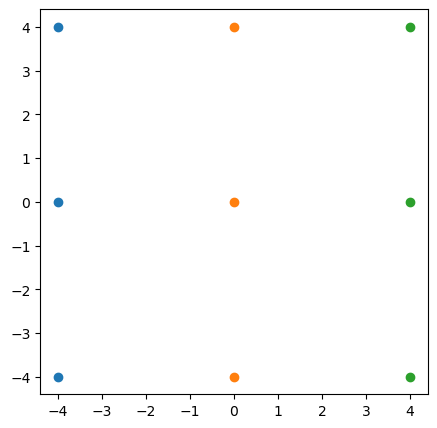

In [13]:
# Configure grid (arrays in µrad)
# npoints = 11
# angsx = np.linspace(-10, 10, npoints)
# angsy = np.linspace(-10, 10, npoints)

# configure grid manually
# angsx = np.array([-10, -4, -2, 0, 2, 4, 10])
# angsy = np.array([-10, -4, -2, 0, 2, 4, 10])
angsx = np.array([-4, 0, 4])
angsy = np.array([-4, 0, 4])

x, y = np.meshgrid(angsx, angsy)
plt.figure(figsize=(5, 5))
plt.plot(x, y, 'o')

### Measurement Functions

In [ ]:
def get_xbpm_readings(
        xbpmlist: list, 
        names: list, 
        nr_meas=10, 
        tinterval=1
    ):
    blades    = {}
    positions = {}

    for i, xbpm in enumerate(xbpmlist):
        blades[names[i]] = {
            'prefix': xbpm.prefix,
            'A_val': [],
            'B_val': [],
            'C_val': [],
            'D_val': [],
            'A_range': [],
            'B_range': [],
            'C_range': [],
            'D_range': [],
            'A_saturation': [],
            'B_saturation': [],
            'C_saturation': [],
            'D_saturation': [],
        }

        positions[names[i]] = {
            'prefix': xbpm.prefix,
            'X_pos' : [],
            'Y_pos' : [],
        } 

    for _ in np.arange(nr_meas):
        for i, xbpm in enumerate(xbpmlist):
            xbpm_ampA = xbpm.ampA()
            xbpm_ampB = xbpm.ampB()
            xbpm_ampC = xbpm.ampC()
            xbpm_ampD = xbpm.ampD()
            
            xbpm_rangeA = xbpm.rangeA()
            xbpm_rangeB = xbpm.rangeB()
            xbpm_rangeC = xbpm.rangeC()
            xbpm_rangeD = xbpm.rangeD()

            xbpm_satA = xbpm.saturatedA()
            xbpm_satB = xbpm.saturatedB()
            xbpm_satC = xbpm.saturatedC()
            xbpm_satD = xbpm.saturatedD()

            xbpm_posX = xbpm.posX()
            xbpm_posY = xbpm.posY()

            blades[names[i]]['A_val'].append(xbpm_ampA)
            blades[names[i]]['B_val'].append(xbpm_ampB)
            blades[names[i]]['C_val'].append(xbpm_ampC)
            blades[names[i]]['D_val'].append(xbpm_ampD)

            blades[names[i]]['A_range'].append(xbpm_rangeA)
            blades[names[i]]['B_range'].append(xbpm_rangeB)
            blades[names[i]]['C_range'].append(xbpm_rangeC)
            blades[names[i]]['D_range'].append(xbpm_rangeD)

            blades[names[i]]['A_saturation'].append(xbpm_satA)
            blades[names[i]]['B_saturation'].append(xbpm_satB)
            blades[names[i]]['C_saturation'].append(xbpm_satC)
            blades[names[i]]['D_saturation'].append(xbpm_satD)

            positions[names[i]]['X_pos'].append(xbpm_posX)
            positions[names[i]]['Y_pos'].append(xbpm_posY)
        time.sleep(tinterval)

    return blades

def get_meas_data(
    blades: dict,
    positions: dict,
    currinfo: CurrInfoSI,
    sofb: SOFB,
    idlist: list,
    subsec='06SB',
    agx=0,
    agy=0,
    psx=0,
    psy=0,
):
    idinfo = {
        'mnc': idlist[0].phase_mon,
        'cnb': idlist[1].gap_mon,
        'cat': idlist[2].gap_mon,
    }

    machinfo = {
        'current': currinfo.current,
        'agx': agx,
        'agy': agy,
        'posx': psx,
        'posy': psy,
        'orbx': sofb.orbx,
        'orby': sofb.orby,
    }

    data = (blades, positions, idinfo, machinfo)

    fname = 'xbpm_acq_subsec:'
    fname += f'{subsec}_agx:{agx:03.0f}_agy:{agy:03.0f}_'
    fname += f'posx:{psx:03.0f}_posy:{psy:03.0f}_'
    fname += 'time_' + str(time.time()) + '.pickle'
    save(data, fname)

    return data

### Bumps Class Parameters

In [ ]:
bump_param = BumpParams()
bump_param.subsec = '06SB'
bump_param.pts_agx = angsx
bump_param.pts_agy = angsy
bump_param.do_angular_bumps = True
bump_param.n_bpms_outx = 4
bump_param.n_bpms_outy = 4
bump_param.minsingval = 1
bump_param.bump_residue = 1
bump_param.bump_max_residue = 10
bump_param.meas_func = get_xbpm_readings
bump_param.args = [[xbpm_cat], ['CAT1']]
print(bump_param)

### Beam Bumping

In [ ]:
# Initialize Bump Class
bump = Bump(bump_param)
bump.get_initial_state()

now = datetime.now()  # noqa: DTZ005
current_time = now.strftime("%Y-%m-%d_%H-%M")

ref_orb_bumps = np.concatenate((bump.reforbx, bump.reforby))
save(ref_orb_bumps, f'ref_orb_bumps_CAT_{current_time}.pickle')

bump.config_sofb()
bump.remove_bpms()

# Start Scan
bump.do_scan()

In [ ]:
# Restore Reference Orbit
bump.restore_initial_state()